In [6]:
!pip install librosa soundfile torch torchaudio scikit-learn matplotlib numpy tqdm -q
print("✅ All packages installed!")

✅ All packages installed!


In [7]:
import os
import io
import base64
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from IPython.display import display, HTML, Audio
from google.colab import output
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports done | Device: {device}')

✅ Imports done | Device: cpu


In [9]:
def save_base64_wav(b64_data, filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    raw_bytes = base64.b64decode(b64_data)
    raw_path = filepath.replace('.wav', '_raw.webm')
    with open(raw_path, 'wb') as f:
        f.write(raw_bytes)
    os.system(f'ffmpeg -y -i "{raw_path}" -ar 16000 -ac 1 "{filepath}" -loglevel quiet')
    os.remove(raw_path)
    print(f'💾 Saved: {filepath}')

output.register_callback('notebook.save_audio', save_base64_wav)

display(HTML("""
<style>
  .rc { font-family: 'Segoe UI', sans-serif; background: #0f0f0f; color: #e0e0e0;
        padding: 24px 28px; border-radius: 14px; max-width: 480px; border: 1px solid #2a2a2a; }
  .rt { font-size: 18px; font-weight: 600; margin-bottom: 18px; color: #fff; }
  .rb { padding: 10px 22px; border-radius: 8px; border: none; font-size: 14px;
        font-weight: 500; cursor: pointer; margin-right: 8px; transition: opacity 0.2s; }
  .rb:disabled { opacity: 0.35; cursor: not-allowed; }
  #bs { background: #ef4444; color: white; }
  #bx { background: #3b82f6; color: white; }
  #bv { background: #22c55e; color: white; }
  .ri { background: #1a1a1a; border: 1px solid #333; color: #e0e0e0;
        padding: 8px 12px; border-radius: 8px; font-size: 14px; width: 180px; margin-right: 8px; }
  .rs { margin-top: 14px; font-size: 13px; color: #9ca3af; min-height: 20px; }
  .rl { margin-top: 12px; font-size: 12px; color: #6b7280; max-height: 90px; overflow-y: auto; }
  .dot { display:inline-block; width:9px; height:9px; border-radius:50%;
         background:#ef4444; animation: blink 1s infinite; margin-right:6px; }
  @keyframes blink { 0%,100%{opacity:1} 50%{opacity:0.2} }
</style>
<div class='rc'>
  <div class='rt'>🎙️ Voice Recorder</div>
  <div style='margin-bottom:14px'>
    <button class='rb' id='bs' onclick='startRec()'>▶ Start</button>
    <button class='rb' id='bx' onclick='stopRec()' disabled>■ Stop</button>
  </div>
  <audio id='prev' controls style='width:100%;margin-bottom:14px;display:none'></audio>
  <div style='display:flex;align-items:center;margin-bottom:10px'>
    <input class='ri' id='sn' placeholder='Speaker name (e.g. alice)' />
    <button class='rb' id='bv' onclick='saveRec()' disabled>💾 Save</button>
  </div>
  <div class='rs' id='st'>Ready. Press Start to record.</div>
  <div class='rl' id='lg'></div>
</div>
<script>
let mr, ac=[], ab=null, cc={};
async function startRec(){
  ac=[];
  const s=await navigator.mediaDevices.getUserMedia({audio:true});
  mr=new MediaRecorder(s);
  mr.ondataavailable=e=>ac.push(e.data);
  mr.start();
  document.getElementById('st').innerHTML="<span class='dot'></span> Recording...";
  document.getElementById('bs').disabled=true;
  document.getElementById('bx').disabled=false;
  document.getElementById('bv').disabled=true;
  document.getElementById('prev').style.display='none';
}
function stopRec(){
  mr.stop(); mr.stream.getTracks().forEach(t=>t.stop());
  mr.onstop=()=>{
    ab=new Blob(ac,{type:'audio/webm'});
    const u=URL.createObjectURL(ab);
    const p=document.getElementById('prev');
    p.src=u; p.style.display='block';
    document.getElementById('st').textContent='✅ Done. Preview above, then save.';
    document.getElementById('bs').disabled=false;
    document.getElementById('bx').disabled=true;
    document.getElementById('bv').disabled=false;
  };
}
function saveRec(){
  const n=document.getElementById('sn').value.trim().toLowerCase().replace(/\s+/g,'_');
  if(!n){alert('Enter a speaker name!');return;}
  if(!ab){alert('No recording!');return;}
  cc[n]=(cc[n]||0)+1;
  const fp='data/'+n+'/clip_'+cc[n]+'.wav';
  const r=new FileReader();
  r.onloadend=()=>{
    const b=r.result.split(',')[1];
    google.colab.kernel.invokeFunction('notebook.save_audio',[b,fp],{});
    document.getElementById('lg').innerHTML+='<div>✔ Saved clip '+cc[n]+' for <b>'+n+'</b></div>';
    document.getElementById('st').textContent='Saved! Record another clip or new speaker.';
  };
  r.readAsDataURL(ab);
}
</script>
"""))
print("\n📋 Record at least 2 speakers, 3 clips each, 3-5 seconds per clip.")
print("Wait for '💾 Saved:' message before recording the next clip.")

<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_12195/629673567.py:74: SyntaxWarning: invalid escape sequence '\s'
  const n=document.getElementById('sn').value.trim().toLowerCase().replace(/\s+/g,'_');



📋 Record at least 2 speakers, 3 clips each, 3-5 seconds per clip.
Wait for '💾 Saved:' message before recording the next clip.
💾 Saved: data/kritika/clip_1.wav
💾 Saved: data/tanya/clip_1.wav
💾 Saved: data/kritika_2/clip_1.wav


In [18]:
print("📁 Dataset structure:")
total, speakers = 0, []
if not os.path.exists('data'):
    print("⚠️  No 'data' folder. Please record audio in Cell 3 first.")
else:
    for spk in sorted(os.listdir('data')):
        p = os.path.join('data', spk)
        if os.path.isdir(p):
            clips = [f for f in os.listdir(p) if f.endswith('.wav')]
            print(f"  🧑 {spk}: {len(clips)} clip(s)")
            total += len(clips)
            speakers.append(spk)
    print(f"\n  Total: {len(speakers)} speaker(s), {total} clip(s)")
    if len(speakers) < 2:
        print("⚠️  Need at least 2 speakers!")
    elif total < 6:
        print("⚠️  Record at least 3 clips per speaker.")
    else:
        print("✅ Ready to train!")

📁 Dataset structure:
  🧑 kritika: 1 clip(s)
  🧑 kritika_2: 1 clip(s)
  🧑 tanya: 1 clip(s)

  Total: 3 speaker(s), 3 clip(s)
⚠️  Record at least 3 clips per speaker.


In [19]:
SR = 16000
DURATION = 3
N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 160

def preprocess_audio(file_path, sr=SR, duration=DURATION):
    audio, _ = librosa.load(file_path, sr=sr, duration=duration + 0.5)
    audio, _ = librosa.effects.trim(audio, top_db=20)
    target = sr * duration
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    return audio

def extract_mfcc(audio, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / (np.std(mfcc, axis=1, keepdims=True) + 1e-8)
    return mfcc

print(f"✅ Functions ready | SR={SR}Hz | Duration={DURATION}s | MFCCs={N_MFCC}")

✅ Functions ready | SR=16000Hz | Duration=3s | MFCCs=40


In [25]:
import soundfile as sf

def augment_and_expand(data_dir='data', clips_per_speaker=5):
    """
    Takes your existing clips and creates augmented versions
    so each speaker has enough clips for triplet training.
    """
    print("🔄 Expanding dataset with augmentations...")

    for spk in os.listdir(data_dir):
        spk_path = os.path.join(data_dir, spk)
        if not os.path.isdir(spk_path):
            continue

        existing = sorted([f for f in os.listdir(spk_path) if f.endswith('.wav')])
        if not existing:
            continue

        print(f"  🧑 {spk}: {len(existing)} original clip(s) → generating more...")

        # Load the first clip as base
        base_path = os.path.join(spk_path, existing[0])
        audio = preprocess_audio(base_path)

        augmentations = []

        # Aug 1: add light noise
        a1 = audio + np.random.normal(0, 0.005, audio.shape)
        augmentations.append(np.clip(a1, -1, 1))

        # Aug 2: slightly louder
        a2 = np.clip(audio * 1.15, -1, 1)
        augmentations.append(a2)

        # Aug 3: slightly quieter
        a3 = audio * 0.80
        augmentations.append(a3)

        # Aug 4: time shift (shift audio 0.2s forward)
        shift = int(SR * 0.2)
        a4 = np.roll(audio, shift)
        a4[:shift] = 0
        augmentations.append(a4)

        # Aug 5: add more noise (different seed)
        a5 = audio + np.random.normal(0, 0.008, audio.shape)
        augmentations.append(np.clip(a5, -1, 1))

        # Save augmented clips
        saved = len(existing)
        for i, aug_audio in enumerate(augmentations):
            save_path = os.path.join(spk_path, f'aug_{i+1}.wav')
            sf.write(save_path, aug_audio, SR)
            saved += 1
            if saved >= clips_per_speaker:
                break

        all_clips = [f for f in os.listdir(spk_path) if f.endswith('.wav')]
        print(f"     ✅ {spk}: now has {len(all_clips)} clips")

    print("\n✅ Dataset expanded!")

augment_and_expand(data_dir='data', clips_per_speaker=6)

🔄 Expanding dataset with augmentations...
  🧑 kritika_2: 1 original clip(s) → generating more...
     ✅ kritika_2: now has 6 clips
  🧑 kritika: 1 original clip(s) → generating more...
     ✅ kritika: now has 6 clips
  🧑 tanya: 1 original clip(s) → generating more...
     ✅ tanya: now has 6 clips

✅ Dataset expanded!


📊 Using: data/kritika_2/aug_1.wav


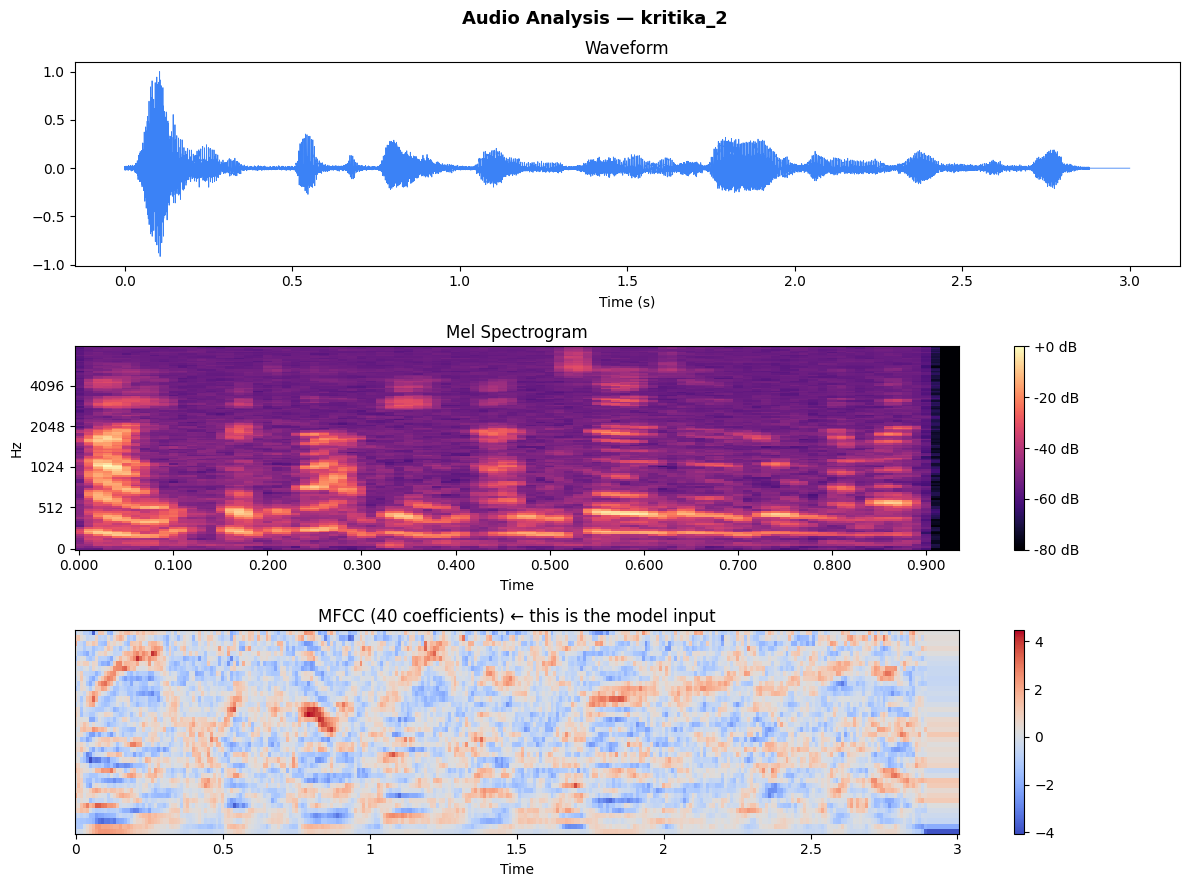

✅ MFCC shape: (40, 301)  →  (40 coefficients  x  301 time frames)


In [26]:
sample_file, sample_spk = None, None
for spk in os.listdir('data'):
    p = os.path.join('data', spk)
    if os.path.isdir(p):
        clips = [f for f in os.listdir(p) if f.endswith('.wav')]
        if clips:
            sample_file = os.path.join(p, clips[0])
            sample_spk = spk
            break

if sample_file is None:
    sample_file = librosa.example('trumpet')
    sample_spk = 'librosa_sample'

print(f"📊 Using: {sample_file}")
audio_raw, _ = librosa.load(sample_file, sr=SR)
display(Audio(audio_raw, rate=SR))

audio = preprocess_audio(sample_file)
mfcc  = extract_mfcc(audio)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle(f'Audio Analysis — {sample_spk}', fontsize=13, fontweight='bold')

axes[0].plot(np.linspace(0, DURATION, len(audio)), audio, color='#3b82f6', lw=0.6)
axes[0].set_title('Waveform'); axes[0].set_xlabel('Time (s)')

mel = librosa.power_to_db(librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128), ref=np.max)
img = librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel Spectrogram')

img2 = librosa.display.specshow(mfcc, sr=SR, hop_length=HOP_LENGTH, x_axis='time', ax=axes[2], cmap='coolwarm')
fig.colorbar(img2, ax=axes[2])
axes[2].set_title(f'MFCC ({N_MFCC} coefficients) ← this is the model input')

plt.tight_layout()
plt.show()
print(f"✅ MFCC shape: {mfcc.shape}  →  (40 coefficients  x  {mfcc.shape[1]} time frames)")

In [27]:
class SpeakerDataset(Dataset):
    def __init__(self, root_dir='data', augment=False):
        self.samples = []
        self.speaker_to_idx = {}
        self.augment = augment

        for idx, spk in enumerate(sorted(os.listdir(root_dir))):
            p = os.path.join(root_dir, spk)
            if not os.path.isdir(p): continue
            self.speaker_to_idx[spk] = idx
            for clip in os.listdir(p):
                if clip.endswith('.wav'):
                    self.samples.append({'path': os.path.join(p, clip), 'speaker_id': idx})

        self.by_speaker = defaultdict(list)
        for i, s in enumerate(self.samples):
            self.by_speaker[s['speaker_id']].append(i)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        audio = preprocess_audio(item['path'])
        if self.augment and random.random() < 0.5:
            audio = np.clip(audio + np.random.normal(0, 0.003, audio.shape), -1.0, 1.0)
        mfcc = extract_mfcc(audio)
        return torch.FloatTensor(mfcc).unsqueeze(0), item['speaker_id']

dataset = SpeakerDataset(root_dir='data', augment=True)
num_speakers = len(dataset.speaker_to_idx)
print(f"✅ Dataset loaded")
print(f"   Speakers : {list(dataset.speaker_to_idx.keys())}")
print(f"   Total clips : {len(dataset)}")
print(f"   Tensor shape per sample: {dataset[0][0].shape}  → (1 channel, 40 mfcc, time_frames)")

✅ Dataset loaded
   Speakers : ['kritika', 'kritika_2', 'tanya']
   Total clips : 18
   Tensor shape per sample: torch.Size([1, 40, 301])  → (1 channel, 40 mfcc, time_frames)


In [28]:
class VoiceEmbeddingModel(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return nn.functional.normalize(x, p=2, dim=1)  # L2 normalize

model = VoiceEmbeddingModel(embedding_dim=128).to(device)
dummy = torch.randn(2, 1, 40, 301).to(device)
out   = model(dummy)
print(f"✅ Model ready on {device}")
print(f"   Params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"   In shape : {dummy.shape}")
print(f"   Out shape: {out.shape}  ← 128-d voice embedding per clip")
print(f"   Out norm : {out.norm(dim=1).mean().item():.4f}  ← should be 1.0")

✅ Model ready on cpu
   Params   : 650,560
   In shape : torch.Size([2, 1, 40, 301])
   Out shape: torch.Size([2, 128])  ← 128-d voice embedding per clip
   Out norm : 1.0000  ← should be 1.0


In [29]:
class TripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = 1 - (anchor * positive).sum(dim=1)
        neg_dist = 1 - (anchor * negative).sum(dim=1)
        return torch.clamp(pos_dist - neg_dist + self.margin, min=0.0).mean()

criterion = TripletLoss(margin=0.3)
print("✅ Triplet Loss ready")
print("   Goal: same-speaker clips pulled together, different-speaker clips pushed apart")

✅ Triplet Loss ready
   Goal: same-speaker clips pulled together, different-speaker clips pushed apart


In [30]:
def build_triplets(embeddings, labels):
    anchors, positives, negatives = [], [], []
    lnp = labels.cpu().numpy()
    for i in range(len(lnp)):
        same = [j for j in range(len(lnp)) if j != i and lnp[j] == lnp[i]]
        diff = [j for j in range(len(lnp)) if lnp[j] != lnp[i]]
        if not same or not diff:
            continue
        anchors.append(i)
        positives.append(random.choice(same))
        negatives.append(random.choice(diff))
    if not anchors:
        return None, None, None
    ai = torch.tensor(anchors)
    pi = torch.tensor(positives)
    ni = torch.tensor(negatives)
    return embeddings[ai], embeddings[pi], embeddings[ni]


def train_model(model, dataset, epochs=30, lr=0.001):
    # Load ALL samples at once so every batch sees multiple speakers
    bs = len(dataset)
    loader = DataLoader(dataset, batch_size=bs, shuffle=True, drop_last=False)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
    losses = []
    model.train()

    print(f"🚀 Training: {epochs} epochs | batch={bs} (all samples) | device={device}")
    print(f"   Dataset : {len(dataset)} clips across {num_speakers} speakers")
    print("-" * 55)

    for epoch in range(epochs):
        ep_loss, n = 0.0, 0

        for mfccs, labels in loader:
            mfccs  = mfccs.to(device)
            labels = labels.to(device)

            opt.zero_grad()
            emb = model(mfccs)

            a, p, ng = build_triplets(emb, labels)

            if a is None:
                print("⚠️  No valid triplets found in batch — record more clips!")
                continue

            loss = criterion(a, p, ng)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()   # ← optimizer.step() BEFORE scheduler.step()

            ep_loss += loss.item()
            n += 1

        sched.step()  # ← scheduler.step() AFTER optimizer.step()

        if n > 0:
            avg = ep_loss / n
            losses.append(avg)
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}/{epochs}  |  Loss: {avg:.4f}  |  LR: {opt.param_groups[0]['lr']:.6f}")

    print("-" * 55)

    if not losses:
        print("❌ Training failed — no valid triplets were ever built.")
        print("   Fix: record at least 3 clips per speaker (the more the better).")
    else:
        print(f"✅ Done! Final loss: {losses[-1]:.4f}")

    return losses


losses = train_model(model, dataset, epochs=30, lr=0.001)

🚀 Training: 30 epochs | batch=18 (all samples) | device=cpu
   Dataset : 18 clips across 3 speakers
-------------------------------------------------------
  Epoch   1/30  |  Loss: 0.2263  |  LR: 0.001000
  Epoch   5/30  |  Loss: 0.0269  |  LR: 0.001000
  Epoch  10/30  |  Loss: 0.0002  |  LR: 0.000500
  Epoch  15/30  |  Loss: 0.0209  |  LR: 0.000500
  Epoch  20/30  |  Loss: 0.0056  |  LR: 0.000250
  Epoch  25/30  |  Loss: 0.0020  |  LR: 0.000250
  Epoch  30/30  |  Loss: 0.0042  |  LR: 0.000125
-------------------------------------------------------
✅ Done! Final loss: 0.0042


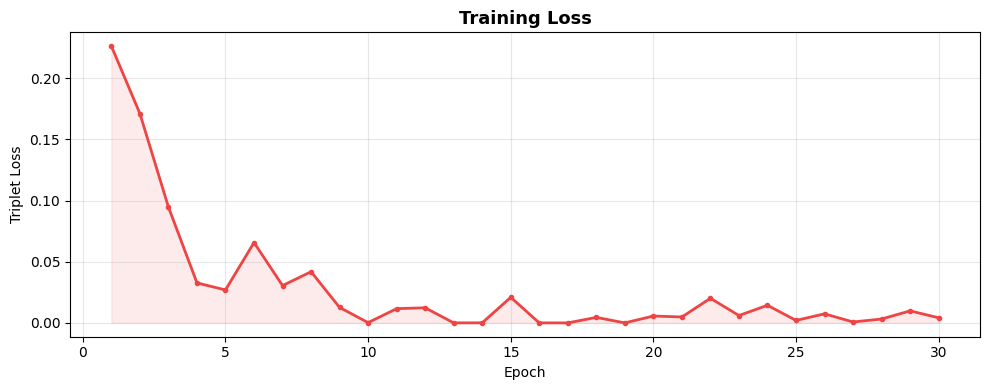

Start: 0.2263  →  End: 0.0042  |  Drop: 98.2%


In [31]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(losses)+1), losses, color='#ef4444', lw=2, marker='o', markersize=3)
plt.fill_between(range(1, len(losses)+1), losses, alpha=0.1, color='#ef4444')
plt.title('Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Triplet Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Start: {losses[0]:.4f}  →  End: {losses[-1]:.4f}  |  Drop: {(losses[0]-losses[-1])/losses[0]*100:.1f}%")

In [32]:
import json
torch.save(model.state_dict(), 'voice_embedding_model.pth')
with open('speaker_map.json', 'w') as f:
    json.dump(dataset.speaker_to_idx, f, indent=2)
print("✅ Saved: voice_embedding_model.pth")
print("✅ Saved: speaker_map.json")

✅ Saved: voice_embedding_model.pth
✅ Saved: speaker_map.json


In [33]:
inf_model = VoiceEmbeddingModel(embedding_dim=128).to(device)
inf_model.load_state_dict(torch.load('voice_embedding_model.pth', map_location=device))
inf_model.eval()
voice_db = {}
print("✅ Model loaded for inference")

✅ Model loaded for inference


In [34]:
def get_embedding(path):
    audio = preprocess_audio(path)
    mfcc  = extract_mfcc(audio)
    t = torch.FloatTensor(mfcc).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = inf_model(t)
    return emb.squeeze().cpu().numpy()

def enroll(name, paths):
    embs = [get_embedding(p) for p in paths]
    avg  = np.mean(embs, axis=0)
    voice_db[name] = avg / np.linalg.norm(avg)
    print(f"✅ Enrolled: {name}  ({len(paths)} clips averaged)")

def verify(claimed_name, test_path, threshold=0.75):
    if claimed_name not in voice_db:
        print(f"❌ Speaker '{claimed_name}' not enrolled.")
        return None, False
    test_emb = get_embedding(test_path)
    stored   = voice_db[claimed_name]
    score    = float(np.dot(test_emb, stored) / (np.linalg.norm(test_emb) * np.linalg.norm(stored)))
    result   = "✅ ACCEPTED" if score >= threshold else "❌ REJECTED"
    print(f"  Speaker : {claimed_name}")
    print(f"  Score   : {score:.4f}  (threshold={threshold})")
    print(f"  Result  : {result}")
    return score, score >= threshold

In [35]:
print("=== ENROLLMENT ===")
for spk in sorted(os.listdir('data')):
    p = os.path.join('data', spk)
    if os.path.isdir(p):
        clips = sorted([os.path.join(p, f) for f in os.listdir(p) if f.endswith('.wav')])
        # Use first 2 clips for enrollment, keep last for testing
        enroll_clips = clips[:2]
        enroll(spk, enroll_clips)

=== ENROLLMENT ===
✅ Enrolled: kritika  (2 clips averaged)
✅ Enrolled: kritika_2  (2 clips averaged)
✅ Enrolled: tanya  (2 clips averaged)


In [36]:
print("=== VERIFICATION ===")
for spk in sorted(os.listdir('data')):
    p = os.path.join('data', spk)
    if os.path.isdir(p):
        clips = sorted([os.path.join(p, f) for f in os.listdir(p) if f.endswith('.wav')])
        if len(clips) >= 2:
            print(f"\n--- Testing: {spk} (own clip → should ACCEPT) ---")
            verify(spk, clips[-1])

# Cross test: verify one speaker's clip against the other (should REJECT)
print("\n=== CROSS-SPEAKER TEST (should REJECT) ===")
all_speakers = sorted([s for s in os.listdir('data') if os.path.isdir(os.path.join('data', s))])
if len(all_speakers) >= 2:
    spk_a = all_speakers[0]
    spk_b = all_speakers[1]
    clips_b = sorted([os.path.join('data', spk_b, f) for f in os.listdir(os.path.join('data', spk_b)) if f.endswith('.wav')])
    print(f"\n--- Claiming to be '{spk_a}' but using '{spk_b}' audio ---")
    verify(spk_a, clips_b[-1])

=== VERIFICATION ===

--- Testing: kritika (own clip → should ACCEPT) ---
  Speaker : kritika
  Score   : 1.0000  (threshold=0.75)
  Result  : ✅ ACCEPTED

--- Testing: kritika_2 (own clip → should ACCEPT) ---
  Speaker : kritika_2
  Score   : 0.9992  (threshold=0.75)
  Result  : ✅ ACCEPTED

--- Testing: tanya (own clip → should ACCEPT) ---
  Speaker : tanya
  Score   : 1.0000  (threshold=0.75)
  Result  : ✅ ACCEPTED

=== CROSS-SPEAKER TEST (should REJECT) ===

--- Claiming to be 'kritika' but using 'kritika_2' audio ---
  Speaker : kritika
  Score   : 0.2822  (threshold=0.75)
  Result  : ❌ REJECTED


=== EMBEDDING SIMILARITY MATRIX ===


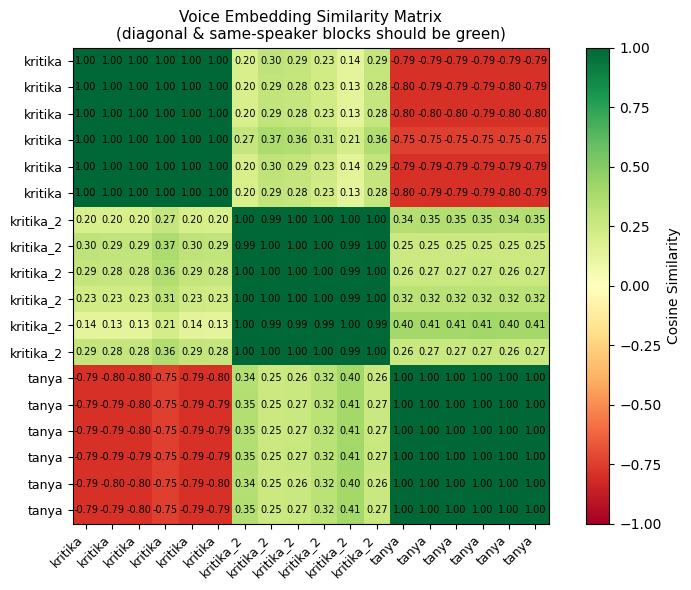

✅ Green = similar voices | Red = different voices
   Same-speaker pairs should be green, cross-speaker pairs should be red/yellow.


In [37]:
print("=== EMBEDDING SIMILARITY MATRIX ===")
all_names, all_embs = [], []

for spk in sorted(os.listdir('data')):
    p = os.path.join('data', spk)
    if os.path.isdir(p):
        clips = sorted([os.path.join(p, f) for f in os.listdir(p) if f.endswith('.wav')])
        for clip in clips:
            all_names.append(spk)
            all_embs.append(get_embedding(clip))

emb_matrix = np.array(all_embs)
sim_matrix  = np.dot(emb_matrix, emb_matrix.T)

plt.figure(figsize=(8, 6))
plt.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(all_names)), all_names, rotation=45, ha='right', fontsize=9)
plt.yticks(range(len(all_names)), all_names, fontsize=9)
plt.title('Voice Embedding Similarity Matrix\n(diagonal & same-speaker blocks should be green)', fontsize=11)
for i in range(len(all_names)):
    for j in range(len(all_names)):
        plt.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()
print("✅ Green = similar voices | Red = different voices")
print("   Same-speaker pairs should be green, cross-speaker pairs should be red/yellow.")

In [39]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [40]:
from google.colab import files

files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>